In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../dataset/final_transformed_data.csv")

data.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0.0,29.85,29.85,0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,1.0,56.95,1889.50,0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,2,0.0,53.85,108.15,1,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,45,1.0,42.30,1840.75,0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2,0.0,70.70,151.65,1,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [3]:
data.shape

(7043, 30)

In [4]:
corr_matrix = data.corr()

corr_matrix.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.016567,-0.142554,0.220173,0.102652,0.150889,-0.001874,0.016479,-0.211185,0.008576,...,-0.182742,-0.060625,-0.182742,0.105378,-0.182742,0.120176,0.156530,-0.024135,0.171718,-0.153477
tenure,0.016567,1.000000,0.671607,0.247900,0.825464,-0.352229,0.005106,0.379697,0.159712,0.008448,...,-0.039062,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.006152,0.233006,-0.208363,-0.233852
Contract,-0.142554,0.671607,1.000000,-0.074195,0.448564,-0.396713,0.000126,0.294806,0.243187,0.002247,...,0.242388,0.293691,0.242388,0.103944,0.242388,0.107520,-0.176733,0.210659,-0.342575,-0.004882
MonthlyCharges,0.220173,0.247900,-0.074195,1.000000,0.650864,0.193356,-0.014569,0.096848,-0.113890,0.247398,...,-0.763557,0.338304,-0.763557,0.629603,-0.763557,0.627429,0.352150,0.030550,0.271625,-0.377437
TotalCharges,0.102652,0.825464,0.448564,0.650864,1.000000,-0.199037,-0.000002,0.318364,0.063593,0.113013,...,-0.374706,0.432329,-0.374706,0.515279,-0.374706,0.519884,0.158055,0.182745,-0.059971,-0.294814


In [7]:

churn_corr = corr_matrix["Churn"].sort_values(
    ascending=False
)

churn_corr


Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


In [8]:
churn_corr.head(10)

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
Name: Churn, dtype: float64

In [9]:
churn_corr.tail(10)

TotalCharges                           -0.199037
InternetService_No                     -0.227890
TechSupport_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
StreamingMovies_No internet service    -0.227890
StreamingTV_No internet service        -0.227890
tenure                                 -0.352229
Contract                               -0.396713
Name: Churn, dtype: float64

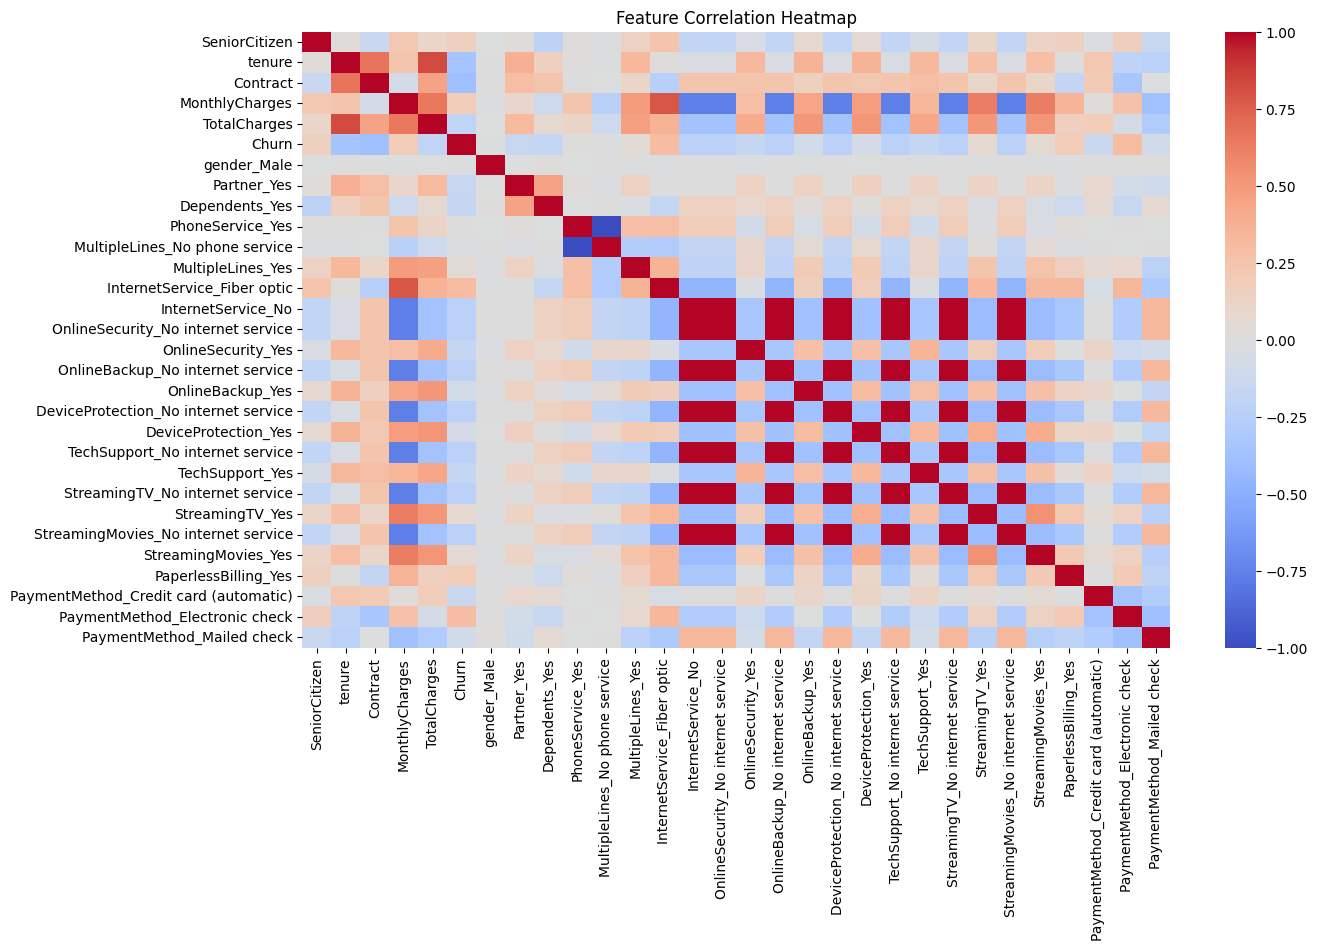

In [10]:
plt.figure(figsize=(14,8))

sns.heatmap(
    data.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [13]:
#Select important features based on correlation.

In [15]:
selected_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "OnlineSecurity_Yes",
    "TechSupport_Yes",
    "InternetService_Fiber optic"
]

selected_features

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Contract',
 'OnlineSecurity_Yes',
 'TechSupport_Yes',
 'InternetService_Fiber optic']

In [17]:
X_selected = data[selected_features]

y = data[["Churn"]]

X_selected.head()

,tenure,MonthlyCharges,TotalCharges,Contract,OnlineSecurity_Yes,TechSupport_Yes,InternetService_Fiber optic
0,1,29.85,29.85,0.0,0.0,0.0,0.0
1,34,56.95,1889.50,1.0,1.0,0.0,0.0
2,2,53.85,108.15,0.0,1.0,0.0,0.0
3,45,42.30,1840.75,1.0,1.0,1.0,0.0
4,2,70.70,151.65,0.0,0.0,0.0,1.0


In [18]:
print(X_selected.shape)
print(y.shape)

(7043, 7)
(7043, 1)


In [19]:
selected_data = pd.concat(
    [X_selected, y],
    axis=1
)



In [21]:
selected_data.head()

,tenure,MonthlyCharges,TotalCharges,Contract,OnlineSecurity_Yes,TechSupport_Yes,InternetService_Fiber optic,Churn
0,1,29.85,29.85,0.0,0.0,0.0,0.0,0
1,34,56.95,1889.50,1.0,1.0,0.0,0.0,0
2,2,53.85,108.15,0.0,1.0,0.0,0.0,1
3,45,42.30,1840.75,1.0,1.0,1.0,0.0,0
4,2,70.70,151.65,0.0,0.0,0.0,1.0,1


In [22]:
selected_data.to_csv(
    "../dataset/selected_features_data.csv",
    index=False
)